In [203]:
import mesa
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

In [204]:
try:
    demographic_distributions = pd.read_csv('demog_distrib.csv')

    region_cols = demographic_distributions[['region', 'total_pop']]
    gender_cols = demographic_distributions[['gender_m', 'gender_f']]
    age_cols = demographic_distributions[['age_<19', 'age_20_29', 'age_30_39', 'age_40_49', 'age_50_59', 'age_60_69', 'age_>70']]
    educ_cols = demographic_distributions[['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']]
    income_cols = demographic_distributions[['below_poverty_line', 'low_income', 'middle_income', 'high_income']]
    split_cols = demographic_distributions[['urban', 'rural']]
except:
    raise FileNotFoundError("The demographic distribution file 'demog_distrib.csv' was not found. Please ensure it is in the correct directory.")
    demographic_distributions = None

issues = {
    'gov': 'Governance', 'edu': 'Education', 'labor': 'Labor', 'sec': 'Security',
    'energy': 'Energy', 'env': 'Environment', 'health': 'Health', 'econ': 'Economy',
    'agri': 'Food & Agriculture', 'crime': 'Anti-Drugs & Crime'
}

In [205]:
class VoterAgent(mesa.Agent):
    """An Voter Agent who Ranks Candidates based on Political Leanings."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.approval_threshold = np.random.uniform(0.4, 0.7) # Approval threshold for voting
        self.ranked_vote = []           # Store Candidate by Rankings
        self.approval_scores = {}

        # Demographic attributes
        try:
            region_probs = region_cols['total_pop']
            self.region_idx = np.random.choice(range(18), p=region_probs)
            self.region = region_cols['region'][self.region_idx]                                                            # Region
            self.gender = np.random.choice(['m', 'f'], p=list(gender_cols.iloc[self.region_idx, :].astype(float).values))   # Gender
            self.age_group = np.random.choice(                                                                              # Age Group
                ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70'],
                p=list(age_cols.iloc[self.region_idx, :].astype(float).values)
            )  
            self.educ_attainment = np.random.choice(                                                                        # Education Attainment
                ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'],
                p=list(educ_cols.iloc[self.region_idx, :].astype(float).values)
            )
            self.income_group = np.random.choice(                                                                           # Income Group
                ['below_poverty_line', 'low_income', 'middle_income', 'high_income'],
                p=list(income_cols.iloc[self.region_idx, :].astype(float).values)
            )
            self.split = np.random.choice(                                                                                  # Urban/Rural Split
                ['urban', 'rural'], 
                p=list(split_cols.iloc[self.region_idx, :].astype(float).values)
            )
        except:
            self.region = 'Unknown'
            self.gender = 'Unknown'
            self.age_group = 'Unknown'
            self.educ_attainment = 'Unknown'
            self.income_group = 'Unknown'
            self.split = 'Unknown'
        
        # Developing Issue Stances and Priorities ----
        self.issue_stances = {}
        self.issue_priorities = {}
        self._initialize_issue_stances_and_priorities()

        # Develop Susceptibility Factors ---
        self._initialize_popularity_influence()

    
    def _initialize_issue_stances_and_priorities(self):
        """Set initial issue stances (positions) and priorities (importance).
           Both stance parameters (a, b for beta dist) and priorities are adjusted
           based on demographic tendencies described in PDF and user-defined stance scales.
        """
        issues = {
            'gov': 'Governance', 'edu': 'Education', 'labor': 'Labor', 'sec': 'Security',
            'energy': 'Energy', 'env': 'Environment', 'health': 'Health', 'econ': 'Economy',
            'agri': 'Food & Agriculture', 'crime': 'Anti-Drugs & Crime'
        }
        self.issues = list(issues.keys())

        # Stance Definitions (User Provided):
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime

        # Initialize base priorities (equal initially) & stance beta parameters (neutral Beta(2,2))
        base_priorities = {issue: 1.0 for issue in self.issues}
        stance_a = {issue: 2.0 for issue in self.issues} # Parameter 'a' for beta(a,b)
        stance_b = {issue: 2.0 for issue in self.issues} # Parameter 'b' for beta(a,b)

        # --- Apply Demographic Adjustments ---
        stance_bias_strength = 0.5 # How much to shift a/b for stance bias
        priority_boost_strength = 0.75 # How much to add for priority boost

        # --- Age Effects ---
        if self.age_group in ['<19', '20-29']:
            # Gov: Less trust -> higher priority, bias towards good gov/reform (1)
            base_priorities['gov'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
            # Edu: Youth concerned re: quality -> higher priority, slight bias towards free/public/quality (1)
            base_priorities['edu'] += np.random.uniform(0.6, priority_boost_strength)
            stance_a['edu'] += stance_bias_strength * 0.5; stance_b['edu'] -= stance_bias_strength * 0.25
            # Econ: Youth concerned re: jobs -> higher priority (stance neutral)
            base_priorities['econ'] += np.random.uniform(0.6, priority_boost_strength)
            # Health: Youth concerned re: health access -> higher priority (stance neutral/slight bias to public=1)
            base_priorities['health'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['health'] += stance_bias_strength * 0.25; stance_b['health'] -= stance_bias_strength * 0.1
            # Energy: Youth advocate renewables -> higher priority & bias towards renewable (1)
            base_priorities['energy'] += np.random.uniform(0.6, priority_boost_strength)
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            # Crime: May favor rehab -> higher priority on issue, bias towards rehab/liberal (1)
            base_priorities['crime'] += np.random.uniform(0.3, 0.5)
            stance_a['crime'] += stance_bias_strength; stance_b['crime'] -= stance_bias_strength * 0.5
        elif self.age_group in ['50-59', '60-69', '>70']:
            # Gov: Higher trust -> lower priority? Bias towards status quo/less reform (0)
            # base_priorities['gov'] -= np.random.uniform(0.1, 0.3) # Optional priority decrease
            stance_a['gov'] -= stance_bias_strength * 0.5; stance_b['gov'] += stance_bias_strength
            # Health: Prioritize senior health needs -> higher priority & bias towards public/free access (1)
            base_priorities['health'] += np.random.uniform(0.7, priority_boost_strength)
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength * 0.5
            # Security: Possibly prioritize safety more [cite: 888 context] -> higher priority & bias towards tight security (0)
            base_priorities['sec'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['sec'] -= stance_bias_strength; stance_b['sec'] += stance_bias_strength*0.5
            # Crime: May prioritize enforcement more -> higher priority & bias towards punitive (0)
            base_priorities['crime'] += np.random.uniform(0.4, 0.6)
            stance_a['crime'] -= stance_bias_strength; stance_b['crime'] += stance_bias_strength * 0.5
            # Economy: Concern re inflation/fixed income -> higher priority (stance likely conservative=0)
            base_priorities['econ'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['econ'] -= stance_bias_strength*0.5; stance_b['econ'] += stance_bias_strength*0.25

        # --- Income Effects ---
        if self.income_group in ['below_poverty_line', 'low_income']:
            # Priorities based on direct needs
            base_priorities['econ'] += np.random.uniform(0.7, priority_boost_strength) # [cite: 919 context] -> bias towards intervention/liberal (1)
            stance_a['econ'] += stance_bias_strength; stance_b['econ'] -= stance_bias_strength*0.5
            base_priorities['labor'] += np.random.uniform(0.7, priority_boost_strength) # [cite: 824 context] -> bias towards more rights (1)
            stance_a['labor'] += stance_bias_strength; stance_b['labor'] -= stance_bias_strength*0.5
            base_priorities['agri'] += np.random.uniform(0.7, priority_boost_strength) # [cite: 932 context] -> bias towards support/liberal (1)
            stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5
            base_priorities['health'] += np.random.uniform(0.6, priority_boost_strength) # [cite: 903 context] -> bias towards public/free (1)
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
            base_priorities['env'] += np.random.uniform(0.2, 0.4) # Immediate impacts [cite: 889 context] -> stance neutral?
            base_priorities['sec'] += np.random.uniform(0.3, 0.5) # Higher fear -> priority [cite: 952 context] (stance neutral?)
            base_priorities['crime'] += np.random.uniform(0.3, 0.5) # Disproportionately affected -> priority [cite: 945 context] (stance neutral?)
        elif self.income_group == 'middle_income':
            # Priorities based on stability/mobility
            base_priorities['econ'] += np.random.uniform(0.5, priority_boost_strength) # [cite: 919 context] (stance neutral?)
            base_priorities['labor'] += np.random.uniform(0.5, priority_boost_strength) # [cite: 825 context] (stance neutral?)
            # Governance: Supported populists -> slight priority increase & bias towards populist (0)
            base_priorities['gov'] += np.random.uniform(0.2, 0.4)
            stance_a['gov'] -= stance_bias_strength*0.5; stance_b['gov'] += stance_bias_strength*0.25
        elif self.income_group == 'high_income':
            # Priorities based on growth/investment
            base_priorities['econ'] += np.random.uniform(0.4, 0.6) # [cite: 921 context] -> bias towards conservative (0)
            stance_a['econ'] -= stance_bias_strength; stance_b['econ'] += stance_bias_strength*0.5
            # Governance: Higher satisfaction -> Bias to status quo (closer to 0.5 or slightly 0?)
            stance_a['gov'] -= stance_bias_strength*0.25; stance_b['gov'] += stance_bias_strength*0.1
            # Environment: Broader sustainability focus [cite: 889 context] -> higher priority & bias to more env care (1)
            base_priorities['env'] += np.random.uniform(0.4, 0.6)
            stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5

        # --- Urban/Rural Effects ---
        if self.split == 'urban':
            base_priorities['sec'] += np.random.uniform(0.5, priority_boost_strength) # Higher crime concerns -> bias towards tight sec (0)?
            stance_a['sec'] -= stance_bias_strength*0.5; stance_b['sec'] += stance_bias_strength*0.25
            base_priorities['labor'] += np.random.uniform(0.4, 0.6) # Focus min wage/security -> bias towards more rights (1)?
            stance_a['labor'] += stance_bias_strength*0.25; stance_b['labor'] -= stance_bias_strength*0.1
            base_priorities['env'] += np.random.uniform(0.4, 0.6) # Focus pollution/dev -> bias towards env care (1)?
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
            base_priorities['econ'] += np.random.uniform(0.4, 0.6) # Focus industry/service jobs (stance neutral?)
            base_priorities['agri'] += np.random.uniform(0.1, 0.3) # Less direct focus (stance neutral?)
            if self.region == 'NCR':
                 base_priorities['gov'] += np.random.uniform(0.4, 0.6) # Less trust -> higher priority & bias towards reform (1)
                 stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
        elif self.split == 'rural':
            base_priorities['labor'] += np.random.uniform(0.6, priority_boost_strength) # Focus agri/off-farm (stance neutral/pro-rights?)
            base_priorities['energy'] += np.random.uniform(0.7, priority_boost_strength) # Prioritize access -> bias towards public/renewables (1)?
            stance_a['energy'] += stance_bias_strength*0.5; stance_b['energy'] -= stance_bias_strength*0.25
            base_priorities['env'] += np.random.uniform(0.6, priority_boost_strength) # Focus resources/agri -> bias towards less env care (0)?
            stance_a['env'] -= stance_bias_strength*0.5; stance_b['env'] += stance_bias_strength*0.25
            base_priorities['health'] += np.random.uniform(0.7, priority_boost_strength) # Prioritize infrastructure -> bias towards public (1)
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
            base_priorities['econ'] += np.random.uniform(0.6, priority_boost_strength) # Focus agri/infrastructure (stance neutral/liberal?)
            base_priorities['agri'] += np.random.uniform(0.7, priority_boost_strength) # Focus subsidies/prices/land reform -> bias towards liberal (1)
            stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5

        # --- Gender Effects ---
        if self.gender == 'f':
            base_priorities['env'] += np.random.uniform(0.4, 0.6) # Stronger concerns -> stance bias towards env care (1)
            stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5
            base_priorities['sec'] += np.random.uniform(0.2, 0.4) # Higher fear [cite: 952 context]
            base_priorities['health'] += np.random.uniform(0.2, 0.4) # Possibly higher health priority (inferred)

        # --- Education Effects ---
        if self.educ_attainment in ['college', 'post_baccalaureate']:
            base_priorities['edu'] += np.random.uniform(0.4, 0.6) # Value quality [cite: 804 context] -> bias towards public/quality (1)
            stance_a['edu'] += stance_bias_strength; stance_b['edu'] -= stance_bias_strength*0.5
            base_priorities['energy'] += np.random.uniform(0.4, 0.6) # Awareness/support renewables -> bias towards renewables (1)
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            base_priorities['health'] += np.random.uniform(0.4, 0.6) # Favor prevention -> bias towards public health (1)
            stance_a['health'] += stance_bias_strength*0.5; stance_b['health'] -= stance_bias_strength*0.25
            base_priorities['env'] += np.random.uniform(0.2, 0.4) # Higher awareness (inferred) -> bias towards env care (1)
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
             base_priorities['sec'] += np.random.uniform(0.2, 0.4) # Higher fear of crime
             base_priorities['energy'] -= np.random.uniform(0.1, 0.3) # Less awareness -> less priority
             base_priorities['env'] -= np.random.uniform(0.1, 0.3) # Less awareness -> less priority

        # --- Final Stance Generation and Priority Normalization ---
        final_stances = {}
        for issue in self.issues:
            # Ensure parameters a and b are positive for beta distribution
            a = max(0.1, stance_a[issue])
            b = max(0.1, stance_b[issue])
            final_stances[issue] = np.random.beta(a, b)
        self.issue_stances = final_stances

        # Normalize priorities
        total_priority = sum(p for p in base_priorities.values() if p > 0)
        if total_priority > 0:
             self.issue_priorities = {k: max(0.0, v) / total_priority for k, v in base_priorities.items()}
        else:
             self.issue_priorities = {issue: 1.0 / len(self.issues) for issue in self.issues}

    def _initialize_popularity_influence(self):
        """Initialize the popularity influence factors for the voter agent."""
        base_influence = np.random.uniform(0.1, 0.4)

        ## Age Adjustments
        if self.age_group in ['<19', '20-29']:
            base_influence += np.random.uniform(0.1, 0.25) # Youth more susceptible to trends and popularity
        elif self.age_group in ['50-59', '60-69', '>70']:
            base_influence -= np.random.uniform(0.05, 0.15) # Older individuals slightly less susceptible to trends

        ## Education Adjustments
        if self.educ_attainment in ['bo_education', 'early_childhood', 'elementary']:
            base_influence += np.random.uniform(0.15, 0.3) # Less education -> more susceptible to trends
        elif self.educ_attainment in ['college', 'post_baccalaureate']:
            base_influence -= np.random.uniform(0.1, 0.25)  # Higher education -> less susceptible to trends

        # Clamp the influence factor to a reasonable range
        self.popularity_influence = max(0.0, min(1.0, base_influence))


    def evaluate_candidate(self, candidate):
        """Evaluate a candidate based on their issue stances and the voter's priorities."""

        # Calculate issue score
        issue_score = 0.0
        if hasattr(candidate, 'issue_stances') and self.issue_stances and self.issue_priorities:
            for issue in self.issues:
                voter_stance = self.issue_stances.get(issue, 0.5)
                candidate_stance = candidate.issue_stances.get(issue, 0.5)
                prioritiy = self.issue_priorities.get(issue, 0.0)

                # Alignment score (1 for perfect opposition, 0 for perfect alignment)
                alignment_score = 1 - abs(voter_stance - candidate_stance)

                # Weight score by priority
                weighted_score = alignment_score * prioritiy
                issue_score += weighted_score

        # Calculate popularity score
        candidate_popularity = getattr(candidate, 'popularity', 0.0)

        # Combine final scores
        final_score = ((1.0 - self.popularity_influence) * issue_score + self.popularity_influence * candidate_popularity)

        return max(0.0, min(1.0, final_score))

    def step(self):
        """Rank Candidates and Vote."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        
        if not candidates:
            return

        scores = {}
        for c in candidates:
            score = self.evaluate_candidate(c)
            scores[c] = score
            self.approval_scores[c.unique_id] = score

        sorted_candidates = sorted(scores.items(), key=lambda item: item[1], reverse=True)
        self.ranked_vote = [candidate for candidate, score in sorted_candidates]

In [206]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.vote_count = 0         # Tracks first-choice votes

        # Politician Types
        types = [
            'Nationalist/Populist', 'Reformist/Technocratic',
            'Traditional/Conservative', 'Social Justice Advocate'
        ]
        self.politician_type = np.random.choice(types)

        # NEW: Initialize issue stances dictionary
        self.issue_stances = {}
        self._initialize_issue_stances()

    def _initialize_issue_stances(self):
        """Set initial issue stances based on the candidate's politician type."""
        issues = [
            'gov', 'edu', 'labor', 'sec', 'energy', 'env',
            'health', 'econ', 'agri', 'crime'
        ]
        stances = {} # Temporary dict to hold base scores

        # Popularity
        self.popularity = np.random.beta(3, 2) # Skew slightly towards higher values

        # Stance Definitions (User Provided):
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime

        if self.politician_type == 'Nationalist/Populist':
            stances = { # Leans towards 0 for gov, env; leans towards 1 for agri, labor, econ (national growth); high for sec, crime (punitive)
                'gov': 0.2, 
                'edu': 0.6, 
                'labor': 0.7, 
                'sec': 0.1, 
                'energy': 0.6, 
                'env': 0.3, 
                'health': 0.6, 
                'econ': 0.3, 
                'agri': 0.8, 
                'crime': 0.1
            }
        elif self.politician_type == 'Reformist/Technocratic':
            stances = { # Leans towards 1 for gov, edu, energy, env, health; balanced for others
                'gov': 0.9, 
                'edu': 0.8, 
                'labor': 0.5, 
                'sec': 0.7, 
                'energy': 0.8, 
                'env': 0.7, 
                'health': 0.8, 
                'econ': 0.6, 
                'agri': 0.6, 
                'crime': 0.5
            }
        elif self.politician_type == 'Traditional/Conservative':
            stances = { # Leans towards 0 for edu, labor, env, econ, agri, crime; mid/low for gov, health, energy; high for sec
                'gov': 0.4, 
                'edu': 0.3, 
                'labor': 0.2, 
                'sec': 0.2, 
                'energy': 0.4, 
                'env': 0.2, 
                'health': 0.4, 
                'econ': 0.2, 
                'agri': 0.3, 
                'crime': 0.2
            }
        elif self.politician_type == 'Social Justice Advocate':
            stances = { # Leans towards 1 for edu, labor, energy, env, health, econ, agri, crime (rehab); mid for gov, sec (human rights focus)
                'gov': 0.7, 
                'edu': 0.9, 
                'labor': 0.9, 
                'sec': 0.6, 
                'energy': 0.9, 
                'env': 0.9, 
                'health': 0.9, 
                'econ': 0.9, 
                'agri': 0.9, 
                'crime': 0.8
            }

        # Apply random variation and clamp between 0 and 1
        for issue in issues:
            base_stance = stances.get(issue, 0.5) # Default to 0.5 if issue missing
            variation = np.random.uniform(-0.25, 0.25) # Add some noise
            self.issue_stances[issue] = max(0.0, min(1.0, base_stance + variation))        

    def step(self):
        # No action yet for this version
        pass

In [207]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner
        self.approval_winner = None     # Track Approval winner

        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self)
            self.schedule.add(v)
        
        # Create Candidates
        for i in range(self.num_candidates):
            c = CandidateAgent(f"c{i}", self)
            self.schedule.add(c)

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Run plurality voting
        print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()

        # Run Approval Voting
        print("\n===== APPROVAL VOTING =====")
        self._approval_voting()
        
        # Compare the results
        self._announce_winner()

    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote:
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1


    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        print(f'-- Plurality Election Results --')
        print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {candidate.vote_count}")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
        if potential_winners:
            self.plurality_winner = np.random.choice(potential_winners)
        else:
            self.plurality_winner = None

        if self.plurality_winner:
            print(f'Plurality Winner: {self.plurality_winner.unique_id} (Votes: {self.plurality_winner.vote_count})')
        else:
            print('No winner determined.')

    
    ### IRV VOTING ###
    def _irv_election(self):
        """Run IRV Election Process"""
        print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # Print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                print(f"  Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {count} ({count/total_votes_cast:.2%})")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
        else:
            print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None

    ### APPROVAL VOTING ###
    def _approval_voting(self):
        """Run Approval Voting."""
        print(f'-- Aproval Voting Results --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        approval_counts = defaultdict(int)

        # Tally approval votes for each candidate
        for voter in voters:
            for candidate in candidates:
                # Get the pre-calculated score for this candidate
                score = voter.approval_scores.get(candidate.unique_id, 0.0)
                # Check against the voter's score threshold
                if score >= voter.approval_threshold:
                    approval_counts[candidate] += 1

        max_approvals = -1
        potential_winners = []

        sorted_approvals = sorted(approval_counts.items(), key=lambda x: x[1], reverse=True)

        print(f'Total Candidates: {len(candidates)}')
        for candidate, count in sorted_approvals:
            print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Approvals: {count}")
            if count > max_approvals:
                max_approvals = count
                potential_winners = [candidate]
            elif count == max_approvals:
                potential_winners.append(candidate)

        if potential_winners:
            self.approval_winner = np.random.choice(potential_winners)
            print(f'\nWinner: {self.approval_winner.unique_id} (Approvals: {approval_counts[self.approval_winner]})')
        else:
            self.approval_winner = None
            print("No winner determined.")


        

    ### ANNOUNCE WINNER ###
    def _announce_winner(self):
        """Compare and announce the voting results from both methods."""
        print("\n===== ELECTION COMPARISON =====")
        print("PLURALITY WINNER: ", end="")
        if self.plurality_winner:
            print(f"Candidate {self.plurality_winner.unique_id} (Votes: {self.plurality_winner.vote_count})")
        else:
            print("No winner determined.")
            
        print("IRV WINNER: ", end="")
        if self.irv_winner:
            print(f"Candidate {self.irv_winner.unique_id} (Votes: {self.irv_winner.vote_count})")
        else:
            print("No winner determined.")
            
        print("APPROVAL WINNER:  ", end="")
        if self.approval_winner:
            print(f"Candidate {self.approval_winner.unique_id} (Approvals: {self.approval_winner.vote_count})")
        else:
            print("No winner determined.")

        # Comparison Logic
        winners = {self.plurality_winner, self.irv_winner, self.approval_winner}
        winners.discard(None) # Remove None if any method had no winner

        if len(winners) == 1 and self.plurality_winner is not None: # Check if not empty set
             print(f"\nALL METHODS ELECTED THE SAME CANDIDATE: {list(winners)[0].unique_id}")
        elif len(winners) > 1:
             print("\nDIFFERENT WINNERS BETWEEN METHODS!")
        elif len(winners) == 0:
             print("\nNO WINNER DETERMINED BY ANY METHOD.")


        print('-- End of Election --\n')


In [208]:
# Simple Preferences
model = ElectionModel(num_voters=1000, num_candidates=5)

model.step()


===== PLURALITY VOTING =====
-- Plurality Election Results --
Total Candidates: 5
Candidate c0 (Type: Social Justice Advocate) - Votes: 78
Candidate c3 (Type: Reformist/Technocratic) - Votes: 475
Candidate c2 (Type: Nationalist/Populist) - Votes: 401
Candidate c1 (Type: Nationalist/Populist) - Votes: 24
Candidate c4 (Type: Nationalist/Populist) - Votes: 22
Plurality Winner: c3 (Votes: 475)

===== INSTANT RUNOFF VOTING (IRV) =====
-- IRV Election Process --

Round 1 - Candidates Remaining: ['c0', 'c3', 'c1', 'c4', 'c2']
  Candidate c3 (Type: Reformist/Technocratic) - Votes: 475 (47.50%)
  Candidate c2 (Type: Nationalist/Populist) - Votes: 401 (40.10%)
  Candidate c0 (Type: Social Justice Advocate) - Votes: 78 (7.80%)
  Candidate c1 (Type: Nationalist/Populist) - Votes: 24 (2.40%)
  Candidate c4 (Type: Nationalist/Populist) - Votes: 22 (2.20%)
Eliminating Candidate c4 with 22 votes.

Round 2 - Candidates Remaining: ['c0', 'c3', 'c1', 'c2']
  Candidate c3 (Type: Reformist/Technocratic) -

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- NEW VISUALIZATION FUNCTION ---
def plot_demographic_distributions(model):
    """
    Generates bar plots showing the distribution of assigned demographics
    among the voter agents in the simulation.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]

    if not voters:
        print("No voter agents found in the model.")
        return

    # Extract demographic data into a DataFrame
    demo_data = []
    for voter in voters:
        demo_data.append({
            'region': voter.region,
            'gender': voter.gender,
            'age_group': voter.age_group,
            'educ_attainment': voter.educ_attainment,
            'income_group': voter.income_group,
            'split': voter.split
        })
    voter_df = pd.DataFrame(demo_data)

    # Define the demographic categories to plot
    demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']
    num_plots = len(demographic_columns)

    # Create subplots
    # Adjust layout based on the number of plots for better readability
    if num_plots <= 3:
        fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))
        if num_plots == 1: axes = [axes] # Make it iterable if only one plot
    else:
        ncols = 2
        nrows = (num_plots + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows))
        axes = axes.flatten() # Flatten to easily iterate

    fig.suptitle('Distribution of Voter Demographics in Simulation', fontsize=16, y=1.02)

    # Generate count plot for each demographic
    for i, col in enumerate(demographic_columns):
        ax = axes[i]
        # Order bars by frequency for better visualization
        order = voter_df[col].value_counts().index
        sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis')
        ax.set_title(f'Distribution by {col.replace("_", " ").title()}')
        ax.set_xlabel('Number of Voters')
        ax.set_ylabel(col.replace("_", " ").title())

        # Add count labels to bars for clarity
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

    # Hide any unused subplots if the layout is not perfectly filled
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()

In [210]:
# plot_demographic_distributions(model)

In [211]:
def plot_stances_by_demographic(model, demographic_column, plot_type='box'):
    """
    Visualizes voter issue stances grouped by a specific demographic category.

    Args:
        model: The completed ElectionModel instance.
        demographic_column (str): The name of the voter attribute to group by
                                  (e.g., 'income_group', 'age_group', 'split').
        plot_type (str): Type of plot to use ('box' or 'violin'). Default is 'box'.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    if not voters:
        print("No voter agents found in the model.")
        return

    # Extract stance and demographic data
    data_list = []
    for voter in voters:
        if hasattr(voter, 'issue_stances') and hasattr(voter, demographic_column):
            demo_value = getattr(voter, demographic_column)
            for issue, stance in voter.issue_stances.items():
                data_list.append({
                    'VoterID': voter.unique_id, # Optional, but good practice
                    demographic_column: demo_value,
                    'Issue': issue,
                    'Stance': stance
                })

    if not data_list:
        print(f"No stance or demographic data found for column '{demographic_column}'.")
        return

    stance_df = pd.DataFrame(data_list)

    # Determine unique demographic categories and sort them if possible (e.g., age)
    categories = sorted(stance_df[demographic_column].unique())
    if demographic_column == 'age_group': # Custom sort for age
         age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']
         categories = [cat for cat in age_order if cat in categories]
    # Add other custom sorts if needed (e.g., income)
    elif demographic_column == 'income_group':
         income_order = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
         categories = [cat for cat in income_order if cat in categories]
    elif demographic_column == 'educ_attainment':
         edu_order = ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']
         categories = [cat for cat in edu_order if cat in categories]


    print(f"\nVisualizing Issue Stances by {demographic_column.replace('_', ' ').title()}...")

    # Use seaborn's catplot for easy faceting by issue
    plot_kind = plot_type if plot_type in ['box', 'violin'] else 'box'
    g = sns.catplot(
        data=stance_df,
        x=demographic_column,
        y='Stance',
        col='Issue',  # Create a separate plot column for each issue
        kind=plot_kind, # Use boxplot or violinplot
        col_wrap=3,   # Arrange plots in N columns (adjust as needed)
        sharey=True,  # Keep the y-axis (Stance) consistent
        height=4,     # Height of each facet
        aspect=1.2,   # Aspect ratio of each facet
        order=categories, # Use sorted categories for x-axis
        palette='viridis',
        legend=False
    )

    g.fig.suptitle(f'Voter Issue Stances by {demographic_column.replace("_", " ").title()}', y=1.03, fontsize=16)
    g.set_axis_labels(demographic_column.replace("_", " ").title(), "Stance (0-1)")
    g.set_titles("Issue: {col_name}")
    g.set(ylim=(0, 1)) # Ensure y-axis is 0 to 1

    # Improve layout and readability
    g.fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    # Rotate x-axis labels if they overlap
    for ax in g.axes.flatten():
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', linestyle='--', alpha=0.7)


    plt.show()

# # Visualize stances grouped by different demographics:
# plot_stances_by_demographic(model, 'income_group', plot_type='violin')
# plot_stances_by_demographic(model, 'age_group', plot_type='box')
# plot_stances_by_demographic(model, 'split', plot_type='violin')
# plot_stances_by_demographic(model, 'gender', plot_type='box')
# plot_stances_by_demographic(model, 'educ_attainment', plot_type='violin')
# plot_stances_by_demographic(model, 'region', plot_type='box')

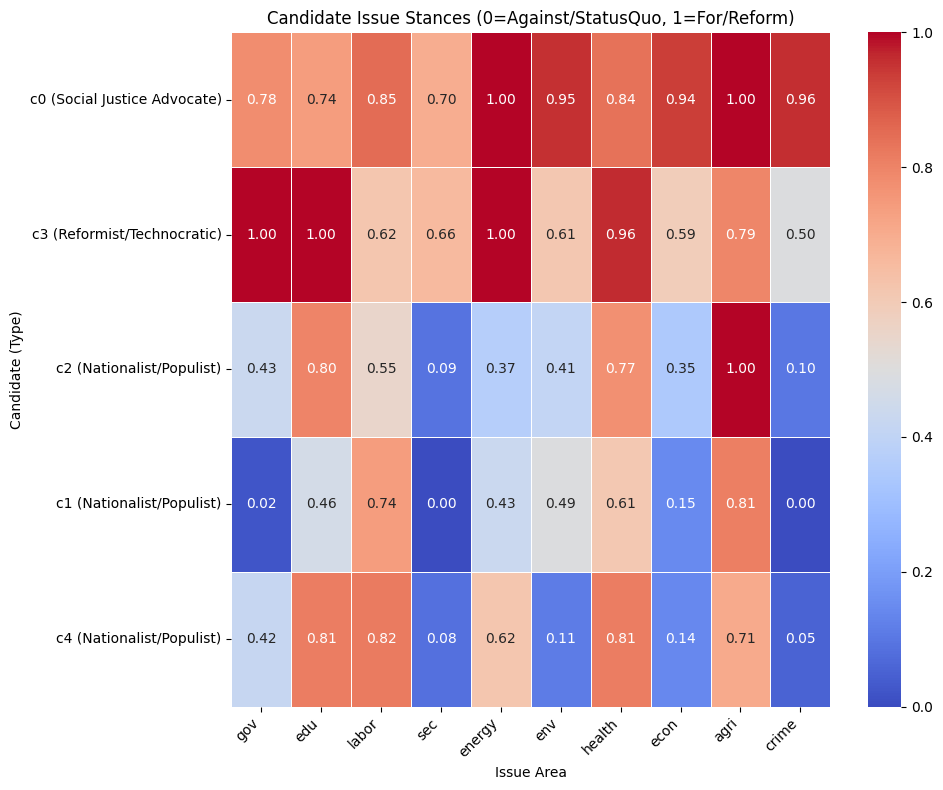

In [212]:
def plot_candidate_issue_stances(model):
    """
    Generates a heatmap visualizing the issue stances of all candidates.
    """
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]

    if not candidates:
        print("No candidate agents found in the model.")
        return

    # Extract stance data
    stance_data = []
    for cand in candidates:
        if hasattr(cand, 'issue_stances'):
            # Add candidate info for better labeling
            stance_entry = cand.issue_stances.copy()
            stance_entry['CandidateID'] = cand.unique_id
            stance_entry['Type'] = getattr(cand, 'politician_type', 'Unknown') # Get type if exists
            stance_data.append(stance_entry)

    if not stance_data:
        print("No issue stance data collected from candidates.")
        return

    stance_df = pd.DataFrame(stance_data)

    # Set CandidateID (or a combination with Type) as index for heatmap labels
    stance_df['Label'] = stance_df.apply(lambda row: f"{row['CandidateID']} ({row['Type']})", axis=1)
    stance_df = stance_df.set_index('Label')

    # Select only the issue columns for the heatmap
    issue_columns = [col for col in stance_df.columns if col not in ['CandidateID', 'Type']]
    heatmap_data = stance_df[issue_columns].astype(float) # Ensure numeric type

    # Plot the heatmap
    plt.figure(figsize=(10, 8)) # Adjust size as needed
    sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=0, vmax=1)
    plt.title('Candidate Issue Stances (0=Against/StatusQuo, 1=For/Reform)')
    plt.xlabel('Issue Area')
    plt.ylabel('Candidate (Type)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_candidate_issue_stances(model)

C:\Users\ajalv\AppData\Local\Temp\ipykernel_11776\3084897322.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


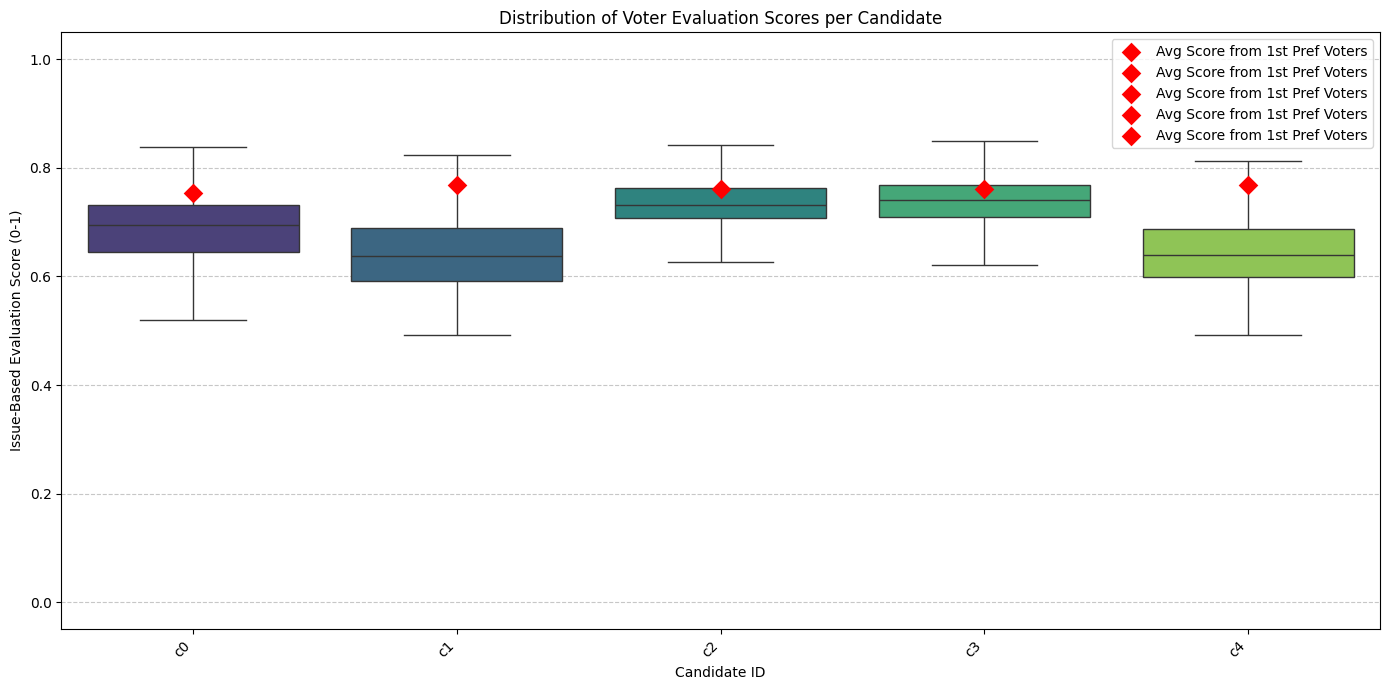

In [213]:
def plot_voter_evaluation_scores(model):
    """
    Visualizes the distribution of evaluation scores received by each candidate,
    with markers for the average score from their first-preference voters.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    plot_data = []
    first_choice_scores = defaultdict(list)

    # Extract scores and identify first choices (based on Plurality logic)
    for voter in voters:
        if not voter.ranked_vote: continue # Skip if voter hasn't ranked
        first_choice_candidate = voter.ranked_vote[0]

        for cand_id, score in voter.approval_scores.items():
            plot_data.append({
                'CandidateID': cand_id,
                'EvaluationScore': score
            })
            # If this candidate was the voter's first choice, store the score
            if cand_id == first_choice_candidate.unique_id:
                first_choice_scores[cand_id].append(score)

    if not plot_data:
        print("No evaluation scores found.")
        return

    eval_df = pd.DataFrame(plot_data)

    # Calculate average scores from first-preference voters
    avg_first_choice_scores = {
        cand_id: np.mean(scores) if scores else 0
        for cand_id, scores in first_choice_scores.items()
    }

    # Prepare data for plotting averages
    avg_plot_data = []
    candidate_order = sorted([c.unique_id for c in candidates]) # Ensure consistent order
    for cand_id in candidate_order:
         if cand_id in avg_first_choice_scores:
             avg_plot_data.append({
                 'CandidateID': cand_id,
                 'AverageScore': avg_first_choice_scores[cand_id]
             })

    avg_df = pd.DataFrame(avg_plot_data)

    # Create the plot
    plt.figure(figsize=(14, 7))

    # Boxplot for all evaluation scores received by each candidate
    sns.boxplot(
        data=eval_df,
        x='CandidateID',
        y='EvaluationScore',
        order=candidate_order,
        palette='viridis',
        showfliers=False # Hide outliers for cleaner plot
    )

    # Overlay average scores from first-preference voters
    if not avg_df.empty:
        sns.stripplot(
            data=avg_df,
            x='CandidateID',
            y='AverageScore',
            order=candidate_order,
            marker='D',    # Diamond marker
            s=10,          # Size of the marker
            color='red',   # Distinct color
            label='Avg Score from 1st Pref Voters',
            jitter=False
        )

    plt.title('Distribution of Voter Evaluation Scores per Candidate')
    plt.xlabel('Candidate ID')
    plt.ylabel('Issue-Based Evaluation Score (0-1)')
    plt.ylim(-0.05, 1.05)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

plot_voter_evaluation_scores(model)